# Perbandingan Algoritma Decision Tree, Random Forest, dan XGBoost untuk Klasifikasi Serangan Jaringan pada Dataset Network Intrusion Detection


## 1. Business Understanding

Permasalahan yang diangkat adalah deteksi intrusi jaringan, yaitu mengidentifikasi apakah sebuah koneksi jaringan termasuk **normal** atau **anomaly**. Karena output yang ingin diprediksi berupa kategori, maka tugas analitik pada project ini termasuk **klasifikasi biner**. Tujuan utama progres ini adalah membandingkan performa tiga model klasifikasi berbasis tree, yaitu model dasar (**Decision Tree**), model ensemble bagging (**Random Forest**), dan model ensemble boosting (**XGBoost**).

## 2. Metode yang Digunakan

| Metode | Alasan Pemilihan | Konsep Dasar |
|---|---|---|
| **Decision Tree** | Baseline berbasis tree yang sederhana dan mudah diinterpretasi | Membangun satu pohon keputusan dengan memilih fitur & threshold terbaik di tiap node (kriteria entropy/Gini) hingga data terklasifikasi |
| **Random Forest** | Pengembangan Decision Tree dengan pendekatan bagging agar prediksi lebih stabil | Melatih banyak tree secara paralel dari subset data & fitur acak, hasil akhir = majority voting |
| **XGBoost** | Model boosting berbasis tree yang kuat untuk data tabular | Membangun tree secara sekuensial, tiap tree baru memperbaiki kesalahan tree sebelumnya (gradient boosting) |

Susunan ini membangun perbandingan bertingkat: **single tree → bagging ensemble → boosting ensemble**.

## 3. Data Understanding


In [1]:
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
url = "https://raw.githubusercontent.com/nashirulwan/ds_rf-xgboost/main/data/raw/Train_data.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (25192, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
print("Data types and non-null counts:")
df.info()

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
display(df["class"].value_counts())

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-nul

duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Duplicate rows: 0

Class distribution:


class
normal     13449
anomaly    11743
Name: count, dtype: int64

### Exploratory Data Analysis (EDA)

EDA dilakukan untuk melihat distribusi target, statistik deskriptif, dan hubungan awal antara fitur dan target.

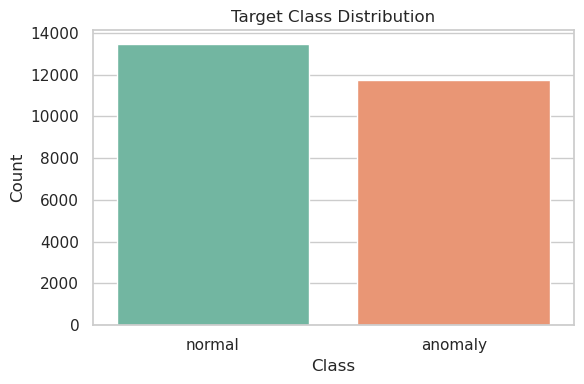

,count,mean,std,min,25%,50%,75%,max
duration,25192.0,305.054104,2.686556e+03,0.0,0.00,0.00,0.00,42862.0
src_bytes,25192.0,24330.628215,2.410805e+06,0.0,0.00,44.00,279.00,381709090.0
dst_bytes,25192.0,3491.847174,8.883072e+04,0.0,0.00,0.00,530.25,5151385.0
land,25192.0,0.000079,8.909946e-03,0.0,0.00,0.00,0.00,1.0
wrong_fragment,25192.0,0.023738,2.602208e-01,0.0,0.00,0.00,0.00,3.0
urgent,25192.0,0.000040,6.300408e-03,0.0,0.00,0.00,0.00,1.0
hot,25192.0,0.198039,2.154202e+00,0.0,0.00,0.00,0.00,77.0
num_failed_logins,25192.0,0.001191,4.541818e-02,0.0,0.00,0.00,0.00,4.0
logged_in,25192.0,0.394768,4.888105e-01,0.0,0.00,0.00,1.00,1.0
num_compromised,25192.0,0.227850,1.041735e+01,0.0,0.00,0.00,0.00,884.0


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(df.describe().T)

## 4. Data Preparation

Tahap preparation meliputi:

1. Mengubah target menjadi biner (`normal = 0`, `anomaly = 1`)
2. Memisahkan fitur `X` dan target `y`
3. Mengidentifikasi fitur kategorikal dan numerik
4. Membagi data menjadi train-test
5. Mengubah fitur kategorikal dengan One-Hot Encoding

In [5]:
df_model = df.copy()
df_model["target"] = (df_model["class"] != "normal").astype(int)

zero_var_cols = ["num_outbound_cmds", "is_host_login"]
df_model = df_model.drop(columns=zero_var_cols)

X = df_model.drop(columns=["class", "target"])
y = df_model["target"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Dropped (zero-variance):", zero_var_cols)
print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))
print("X shape:", X.shape)
print("y shape:", y.shape)
display(y.value_counts().rename(index={0: "normal", 1: "anomaly"}))

Dropped (zero-variance): ['num_outbound_cmds', 'is_host_login']
Categorical features: ['protocol_type', 'service', 'flag']
Number of numeric features: 36
X shape: (25192, 39)
y shape: (25192,)


target
normal     13449
anomaly    11743
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

def make_preprocess():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features),
        ]
    )

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (17634, 39)
Testing set: (7558, 39)


## 5. Modeling

Pipeline preprocessing dan model dasar didefinisikan, kemudian parameter terbaik dicari menggunakan Grid Search.

In [7]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

dt_pipeline = Pipeline([
    ("preprocess", make_preprocess()),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])

rf_pipeline = Pipeline([
    ("preprocess", make_preprocess()),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])

xgb_pipeline = Pipeline([
    ("preprocess", make_preprocess()),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

### Tuning Parameter (Grid Search)

Grid Search mencoba semua kombinasi parameter yang ditentukan dan mengevaluasi tiap kombinasi menggunakan cross-validation, lalu memilih kombinasi dengan F1-score tertinggi sebagai parameter final model.

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    "model__criterion":         ["gini", "entropy"],
    "model__max_depth":         [5, 10, 15],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf":  [2, 4, 8],
}

param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", "log2"],
    "model__max_depth":    [None, 15, 20],
}

param_grid_xgb = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample":     [0.8, 1.0],
}

gs_dt  = GridSearchCV(dt_pipeline,  param_grid_dt,  cv=5, scoring="f1", n_jobs=-1, refit=True)
gs_rf  = GridSearchCV(rf_pipeline,  param_grid_rf,  cv=5, scoring="f1", n_jobs=-1, refit=True)
gs_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring="f1", n_jobs=-1, refit=True)

gs_dt.fit(X_train, y_train)
gs_rf.fit(X_train, y_train)
gs_xgb.fit(X_train, y_train)

dt_best  = gs_dt.best_estimator_
rf_best  = gs_rf.best_estimator_
xgb_best = gs_xgb.best_estimator_

def show_cv_results(gs, model_name, param_grid):
    df = pd.DataFrame(gs.cv_results_)
    param_cols = ["param_" + k for k in param_grid.keys()]
    rename = {"param_" + k: k.replace("model__", "") for k in param_grid.keys()}
    rename["mean_test_score"] = "f1_mean"
    rename["std_test_score"]  = "f1_std"
    rename["rank_test_score"] = "rank"
    df = df[param_cols + ["mean_test_score", "std_test_score", "rank_test_score"]]
    df = df.rename(columns=rename).sort_values("rank").reset_index(drop=True)
    df["f1_mean"] = df["f1_mean"].round(4)
    df["f1_std"]  = df["f1_std"].round(4)
    print(f"=== {model_name} — {len(df)} kombinasi ===")
    display(df)

show_cv_results(gs_dt,  "Decision Tree", param_grid_dt)
show_cv_results(gs_rf,  "Random Forest", param_grid_rf)
show_cv_results(gs_xgb, "XGBoost",       param_grid_xgb)

print("\n=== Parameter Terbaik ===")
best_params_df = pd.DataFrame([
    {"model": "Decision Tree", **{k.replace("model__", ""): v for k, v in gs_dt.best_params_.items()},  "best_f1_cv": round(gs_dt.best_score_, 4)},
    {"model": "Random Forest", **{k.replace("model__", ""): v for k, v in gs_rf.best_params_.items()},  "best_f1_cv": round(gs_rf.best_score_, 4)},
    {"model": "XGBoost",       **{k.replace("model__", ""): v for k, v in gs_xgb.best_params_.items()}, "best_f1_cv": round(gs_xgb.best_score_, 4)},
]).fillna("-")
with pd.option_context("display.max_colwidth", None):
    display(best_params_df)

=== Decision Tree — 54 kombinasi ===


,criterion,max_depth,min_samples_split,min_samples_leaf,f1_mean,f1_std,rank
0,entropy,10,5,2,0.9962,0.0010,1
1,entropy,15,5,2,0.9956,0.0008,2
2,entropy,15,10,2,0.9954,0.0006,3
3,entropy,10,10,2,0.9953,0.0007,4
4,gini,15,5,2,0.9952,0.0011,5
5,entropy,10,20,2,0.9949,0.0010,6
6,entropy,15,20,2,0.9947,0.0011,7
7,gini,15,10,2,0.9946,0.0013,8
8,entropy,10,10,4,0.9946,0.0007,9
9,entropy,10,5,4,0.9945,0.0006,10


=== Random Forest — 18 kombinasi ===


,n_estimators,max_features,max_depth,f1_mean,f1_std,rank
0,200,log2,None,0.9973,0.0004,1
1,200,log2,20,0.9973,0.0003,2
2,300,log2,20,0.9973,0.0004,3
3,200,sqrt,20,0.9972,0.0002,4
4,300,sqrt,20,0.9972,0.0003,5
5,300,sqrt,None,0.9971,0.0003,6
6,100,log2,None,0.9971,0.0002,7
7,300,log2,None,0.9971,0.0004,8
8,100,sqrt,20,0.9971,0.0004,9
9,100,log2,20,0.9971,0.0004,10


=== XGBoost — 24 kombinasi ===


,n_estimators,max_depth,learning_rate,subsample,f1_mean,f1_std,rank
0,200,6,0.10,1.0,0.9977,0.0006,1
1,200,6,0.10,0.8,0.9976,0.0006,2
2,200,8,0.10,1.0,0.9976,0.0004,3
3,200,4,0.10,0.8,0.9975,0.0005,4
4,200,4,0.10,1.0,0.9975,0.0006,5
5,100,8,0.10,1.0,0.9974,0.0004,6
6,200,8,0.05,1.0,0.9973,0.0004,7
7,200,8,0.10,0.8,0.9973,0.0004,8
8,200,8,0.05,0.8,0.9973,0.0004,9
9,100,8,0.10,0.8,0.9973,0.0003,10



=== Parameter Terbaik ===


,model,criterion,max_depth,min_samples_leaf,min_samples_split,best_f1_cv,max_features,n_estimators,learning_rate,subsample
0,Decision Tree,entropy,10.0,2.0,5.0,0.9962,-,-,-,-
1,Random Forest,-,-,-,-,0.9973,log2,200.0,-,-
2,XGBoost,-,6.0,-,-,0.9977,-,200.0,0.1,1.0


## 6. Model Evaluation

Evaluasi dilakukan pada test set (30% data) menggunakan model terbaik hasil grid search.

In [9]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall_sensitivity": recall_score(y_test, y_pred),
        "specificity": specificity,
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "false_positive": fp,
        "false_negative": fn,
    }

results = [
    evaluate_model("Decision Tree", dt_best, X_test, y_test),
    evaluate_model("Random Forest", rf_best, X_test, y_test),
    evaluate_model("XGBoost", xgb_best, X_test, y_test),
]

results_df = pd.DataFrame(results)

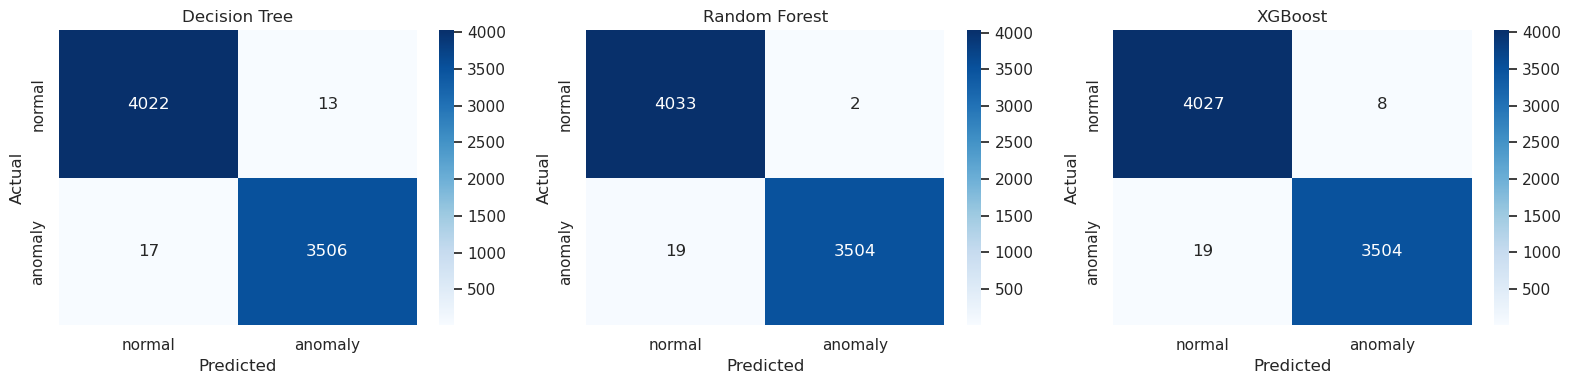

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name, model in zip(
    axes,
    ["Decision Tree", "Random Forest", "XGBoost"],
    [dt_best, rf_best, xgb_best],
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "anomaly"],
        yticklabels=["normal", "anomaly"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [11]:
display(results_df.sort_values("f1_score", ascending=False).reset_index(drop=True).round(4))

,model,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,false_positive,false_negative
0,Random Forest,0.9972,0.9994,0.9946,0.9995,0.9970,0.9999,2,19
1,XGBoost,0.9964,0.9977,0.9946,0.9980,0.9962,1.0000,8,19
2,Decision Tree,0.9960,0.9963,0.9952,0.9968,0.9957,0.9967,13,17


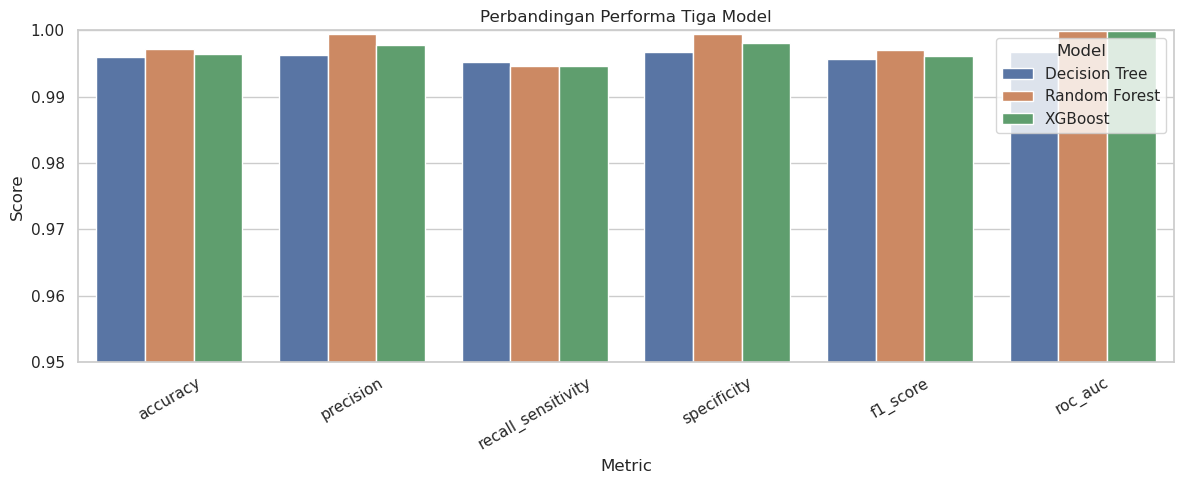

In [12]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
]

results_melted = results_df.melt(
    id_vars="model",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_melted, x="metric", y="score", hue="model")
plt.ylim(0.95, 1.0)
plt.title("Perbandingan Performa Tiga Model")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

**Best model: XGBoost** . F1-score tertinggi pada grid search Cross Validation dan performa paling stabil. Random Forest menjadi alternatif yang setara. Decision Tree tertinggal terutama pada false positive.